### Project 1: BRFSS Mental Health Analysis
#### Notebook 02: Exploratory Data Analysis
**Author:** Amanda Shero  
**Date:** March 2026  
**Description:** Loads the 2023 BRFSS dataset prepped for EDA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_clean.csv')

In [3]:
df.shape

(433323, 25)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Data columns (total 25 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _AGEG5YR  425544 non-null  float64
 1   SEXVAR    433323 non-null  float64
 2   _RACE     423753 non-null  float64
 3   EDUCA     430998 non-null  float64
 4   INCOME3   346700 non-null  float64
 5   MARITAL   429034 non-null  float64
 6   EMPLOY1   425642 non-null  float64
 7   _URBSTAT  425000 non-null  float64
 8   GENHLTH   432061 non-null  float64
 9   PHYSHLTH  422538 non-null  float64
 10  ADDEPEV3  430736 non-null  float64
 11  DIABETE4  432339 non-null  float64
 12  CVDINFR4  430755 non-null  float64
 13  ASTHMA3   431622 non-null  float64
 14  HAVARTH4  430763 non-null  float64
 15  CHCCOPD3  431257 non-null  float64
 16  EXERANY2  432072 non-null  float64
 17  SMOKDAY2  158280 non-null  float64
 18  AVEDRNK3  209735 non-null  float64
 19  DRNK3GE5  209148 non-null  float64
 20  _HLTHPL1  41464

In [5]:
df.dtypes

_AGEG5YR    float64
SEXVAR      float64
_RACE       float64
EDUCA       float64
INCOME3     float64
MARITAL     float64
EMPLOY1     float64
_URBSTAT    float64
GENHLTH     float64
PHYSHLTH    float64
ADDEPEV3    float64
DIABETE4    float64
CVDINFR4    float64
ASTHMA3     float64
HAVARTH4    float64
CHCCOPD3    float64
EXERANY2    float64
SMOKDAY2    float64
AVEDRNK3    float64
DRNK3GE5    float64
_HLTHPL1    float64
MEDCOST1    float64
PERSDOC3    float64
MENTHLTH    float64
_MENT14D    float64
dtype: object

In [6]:
# number of missing values for each variable
df.isna().sum()

_AGEG5YR      7779
SEXVAR           0
_RACE         9570
EDUCA         2325
INCOME3      86623
MARITAL       4289
EMPLOY1       7681
_URBSTAT      8323
GENHLTH       1262
PHYSHLTH     10785
ADDEPEV3      2587
DIABETE4       984
CVDINFR4      2568
ASTHMA3       1701
HAVARTH4      2560
CHCCOPD3      2066
EXERANY2      1251
SMOKDAY2    275043
AVEDRNK3    223588
DRNK3GE5    224175
_HLTHPL1     18674
MEDCOST1      1538
PERSDOC3      4234
MENTHLTH      8108
_MENT14D      8108
dtype: int64

In [7]:
# number of unique values for each variable
df.nunique()

_AGEG5YR    13
SEXVAR       2
_RACE        8
EDUCA        6
INCOME3     11
MARITAL      6
EMPLOY1      8
_URBSTAT     2
GENHLTH      5
PHYSHLTH    31
ADDEPEV3     2
DIABETE4     4
CVDINFR4     2
ASTHMA3      2
HAVARTH4     2
CHCCOPD3     2
EXERANY2     2
SMOKDAY2     3
AVEDRNK3    50
DRNK3GE5    46
_HLTHPL1     2
MEDCOST1     2
PERSDOC3     3
MENTHLTH    31
_MENT14D     3
dtype: int64

#### Target variables

In [8]:
# Days during past 30 days mental health was not good
df['MENTHLTH'].value_counts(dropna=False).head(10)

MENTHLTH
0.0     257026
30.0     25573
2.0      23878
5.0      19959
10.0     15426
3.0      15394
1.0      14173
15.0     14152
20.0      9065
NaN       8108
Name: count, dtype: int64

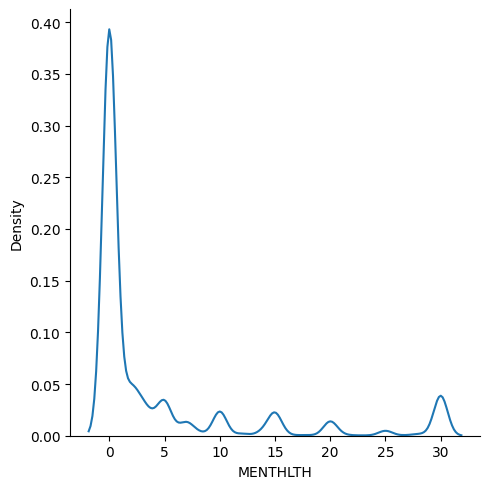

In [9]:
sns.displot(data=df, x='MENTHLTH', kind='kde')
plt.show()

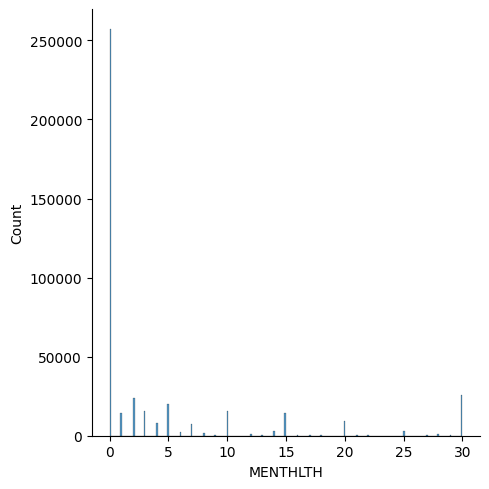

In [10]:
sns.displot(data=df, x='MENTHLTH', kind='hist')
plt.show()

Over 250,000 people (out of 433,323) reported zero mental health days.

There is also a spike at 30 days - the maximum amount that can be recorded (so every day of the month).

There are noticeable humps at the 5, 10, 15, 20 marks - round numbers; referred to as heaping and is common in self-reported survey data (people tend to round to the nearest 5).

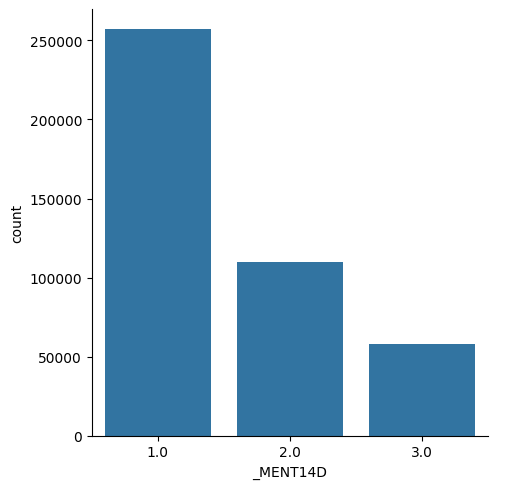

In [11]:
sns.catplot(data=df, x='_MENT14D', kind='count')
plt.show()

* Category 1 (zero bad days) ~258,000 people, by far the largest group
* Category 2 (1–13 days) ~110,000 people
* Category 3 (14+ days, "frequent mental distress") ~60,000 people

#### Demographics

In [12]:
educa_labels = {
    1: "No school/Kindergarten",
    2: "Grades 1-8",
    3: "Grades 9-11",
    4: "Grade 12 or GED",
    5: "College 1-3 years",
    6: "College Graduate 4+ years"
}

df['EDUCA_label'] = df['EDUCA'].map(educa_labels)

In [13]:
df['EDUCA_label'].value_counts()

EDUCA_label
College Graduate 4+ years    184867
College 1-3 years            114346
Grade 12 or GED              106613
Grades 9-11                   16161
Grades 1-8                     8324
No school/Kindergarten          687
Name: count, dtype: int64

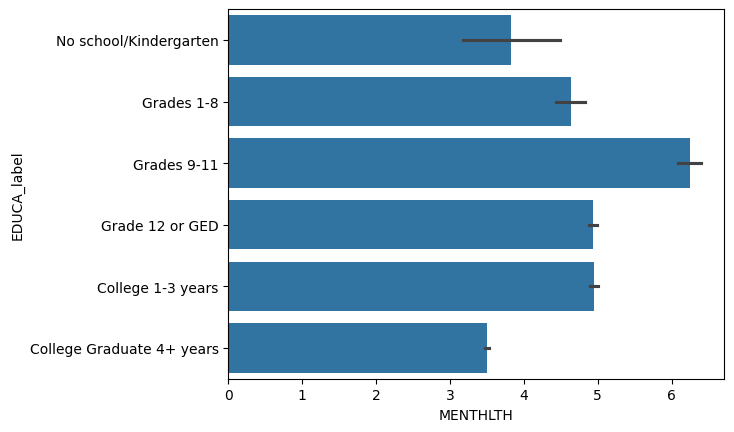

In [14]:
sns.barplot(data=df, x='MENTHLTH', y='EDUCA_label', 
            order=['No school/Kindergarten', 'Grades 1-8', 'Grades 9-11', 'Grade 12 or GED', 'College 1-3 years', 'College Graduate 4+ years'])
plt.show()

No school/Kindergarten is relatlively low but has a very wide confidence interval (small group, high uncertainty).

Elementary through some high school has increasing amount of poor mental health days with some high school having the highest number of poor mental health days overall.

High school graduate and some college are very similar.

College graduate has the lowest poor mental health days overall.

The peak with some high school (grades 9-11) suggest that incomplete secondary education is associated with the worst mental health outcomes, more so than having no formal education at all.

In [15]:
income3_labels = {
    1: "Less than 10K",
    2: "Less than 15K",
    3: "Less than 20K",
    4: "Less than 25K",
    5: "Less than 35K",
    6: "Less than 50K",
    7: "Less than 75K",
    8: "Less than 100K",
    9: "Less than 150K",
    10: "Less than 200K",
    11: "200K or more"
}

df['INCOME3_label'] = df['INCOME3'].map(income3_labels)

In [16]:
df['INCOME3_label'].value_counts()

INCOME3_label
Less than 75K     57896
Less than 150K    52284
Less than 100K    49131
Less than 50K     47502
Less than 35K     38508
200K or more      26770
Less than 200K    24353
Less than 25K     18202
Less than 20K     12867
Less than 15K      9907
Less than 10K      9280
Name: count, dtype: int64

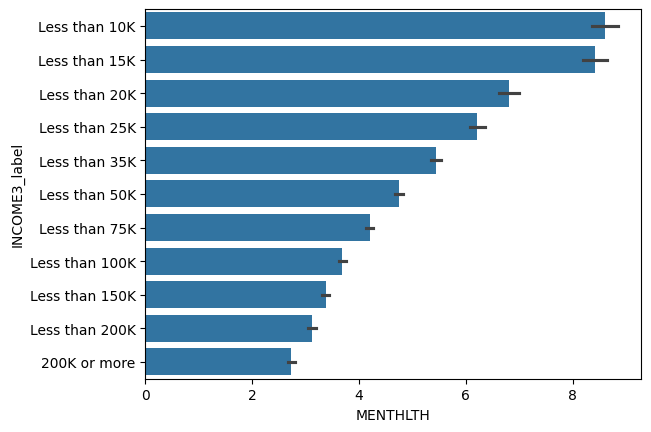

In [17]:
sns.barplot(data=df, x='MENTHLTH', y='INCOME3_label', 
            order=["Less than 10K", "Less than 15K", "Less than 20K", "Less than 25K", "Less than 35K", "Less than 50K", 
                   "Less than 75K", "Less than 100K", "Less than 150K", "Less than 200K", "200K or more"])
plt.show()

Every income step up is associated with fewer poor mental health days.

The magnitude between people earning less than $10K and people earning more than $150K is an almost 3x difference: people earning less than $10K report on average ~8.5 poor mental health days per month while those earning $150K or more report ~3 poor mental health days per month.

The confidence intervals are widest at the lowest income brackets, where the lowest income group has high uncertainty (it's a smaller and more heterogenous group).

In [18]:
urbstat_labels = {
    1: "Urban",
    2: "Rural"
}

df['URBSTAT_label'] = df['_URBSTAT'].map(urbstat_labels)

In [19]:
df['URBSTAT_label'].value_counts()

URBSTAT_label
Urban    369363
Rural     55637
Name: count, dtype: int64

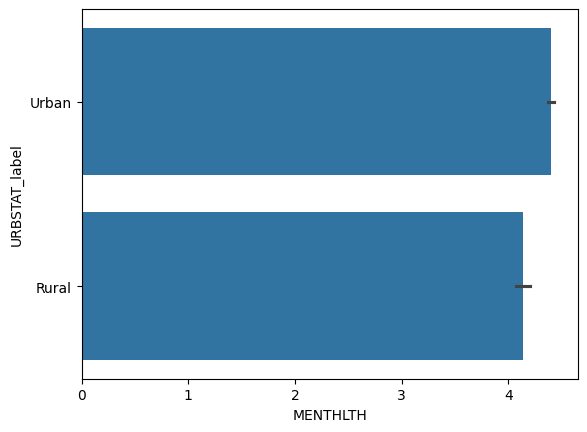

In [20]:
sns.barplot(data=df, x='MENTHLTH', y='URBSTAT_label', order=["Urban", "Rural"])
plt.show()

Small difference between Urban and Rural (~4.4 days vs ~4.6 days respectively) and possible overlapping on the confidence intervals which suggests that this difference may not even be statistically significant.

The lack of a strong divide between Urban and Rural suggests that mental health burden is fairly evenly distributed geographically.

Within the demographic variables explored, more education and higher income are related to a lower number of poor mental health days regardless of an urban vs rural location.

Will want to consider multicollinearity between education and income when modeling if these predictor variables are closely related to each other.

#### Behavioral Factors

In [21]:
exerany2_labels = {
    1: "Yes",
    2: "No"
}

df['EXERANY2_label'] = df['EXERANY2'].map(exerany2_labels)

df['EXERANY2_label'].value_counts()

EXERANY2_label
Yes    325227
No     106845
Name: count, dtype: int64

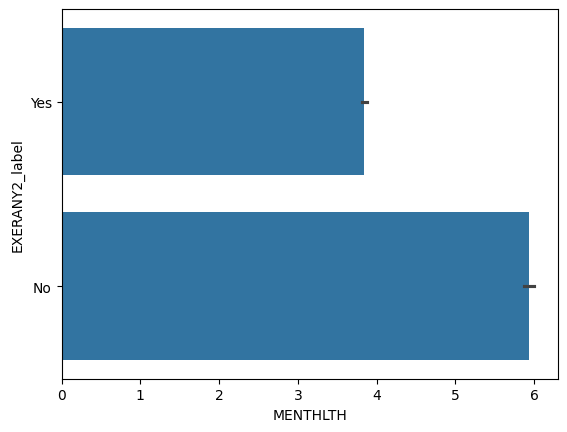

In [22]:
sns.barplot(data=df, x='MENTHLTH', y='EXERANY2_label', order=["Yes", "No"])
plt.show()

Less exercise is related to more poor mental health days.

Need to consider social desirability bias in case exercise is being self-reported at a higher rate than is actually occurring.

Also need to consider reverse causality (bidirectional causality) between exercise and mental health: does more exercise mean better mental health or does better mental health mean more exercise....or both?

In [23]:
smokday2_labels = {
    1: "Every day",
    2: "Some days",
    3: "Not at all"
}

df['SMOKDAY2_label'] = df['SMOKDAY2'].map(smokday2_labels)

df['SMOKDAY2_label'].value_counts()

SMOKDAY2_label
Not at all    113134
Every day      31770
Some days      13376
Name: count, dtype: int64

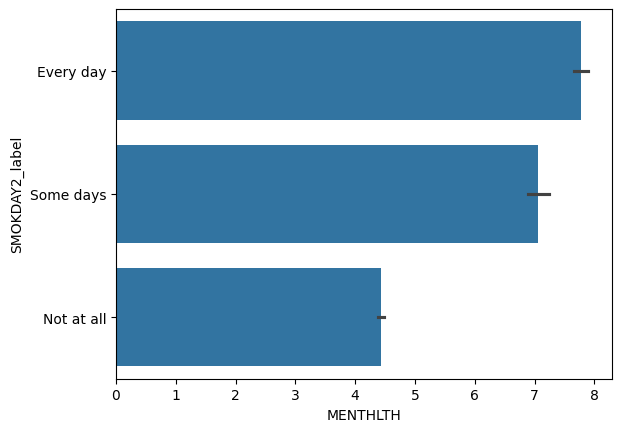

In [24]:
sns.barplot(data=df, x='MENTHLTH', y='SMOKDAY2_label', order=["Every day", "Some days", "Not at all"])
plt.show()

This chart only shows variabion among current or recent smokers, not smokers vs non-smokers since non-smokers who said "No" to the initial smoking question were not asked this question at all.

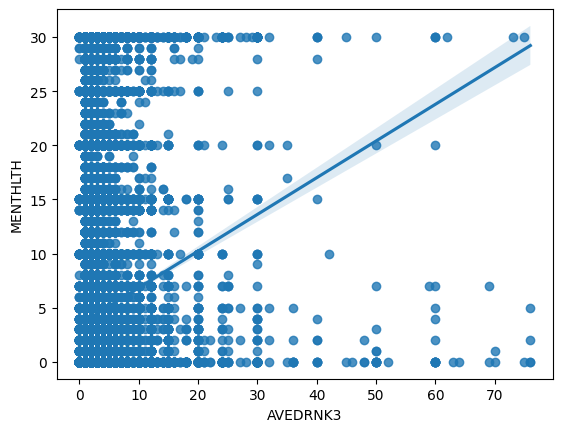

In [25]:
sns.regplot(data=df, x='AVEDRNK3', y='MENTHLTH')
plt.show()

The scatter is extremely wide, especially at lower drink counts. The wide cloud of points around the regression line indicates that AVEDRNK3 alone is a weak predictor — lots of people who drink heavily report zero poor mental health days, and lots of light drinkers report many. The relationship exists but it's noisy.

The heaping pattern is visible again (e.g. at 0, 5, 10, 15, 20, 30 drinks). Same rounding behavior seen in MENTHLTH.

The high end is sparse — very few people report 40, 50, 60, 76 drinks per week, which makes the regression line less reliable out there. Those could be outliers worth examining.

In [26]:
df['AVEDRNK3_bin'] = pd.cut(df['AVEDRNK3'], 
                             bins=[0, 1, 3, 8, 15, 77],
                             labels=['None', '1-2', '3-7', '8-14', '15-76'],
                             right=False)

df['AVEDRNK3_bin'].value_counts()

AVEDRNK3_bin
1-2      158562
3-7       45884
8-14       3830
15-76       823
None        636
Name: count, dtype: int64

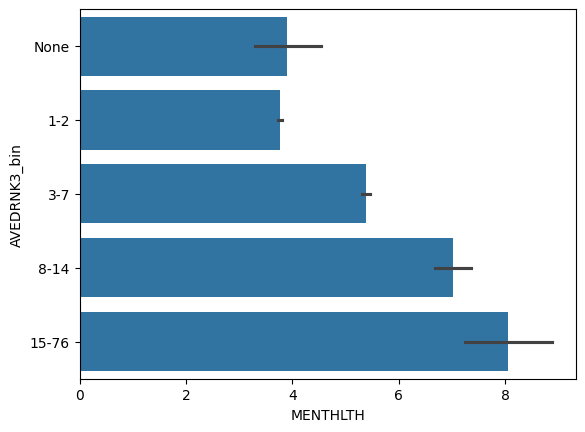

In [27]:
sns.barplot(data=df, x='MENTHLTH', y='AVEDRNK3_bin', order=["None", "1-2", "3-7", "8-14", "15-76"])
plt.show()

The 15-76 has a wide confidence interval so there's more uncertainty around the mean; need to be cautious when interpreting since the sample size in this bin is small.

Similar to SMOKDAY2, if someone reported that they didn't drink, they were not asked this question.

#### Health Status

In [33]:
addepev3_labels = {
    1: "Yes, diagnosis",
    2: "No, diagnosis"
}

df['ADDEPEV3_label'] = df['ADDEPEV3'].map(addepev3_labels)

df['ADDEPEV3_label'].value_counts()

ADDEPEV3_label
No, diagnosis     342587
Yes, diagnosis     88149
Name: count, dtype: int64

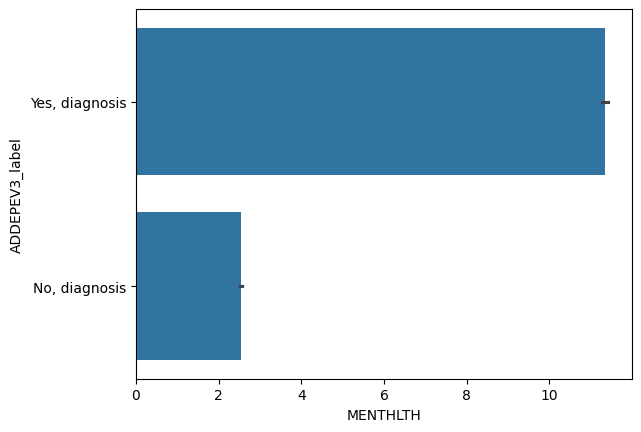

In [34]:
sns.barplot(data=df, x='MENTHLTH', y='ADDEPEV3_label', order=["Yes, diagnosis", "No, diagnosis"])
plt.show()

People with a depression diagnosis report an average of ~11 poor mental health days per month compared to ~2.5 to people without a depression diagnosis (more than a 4x difference).